In [ ]:
# =========================================================
# Task 3: End-to-End Customer Churn Prediction & Web App
# Internship: SYNENT Technologies
# Author: Unnati Gore
# =========================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Dataset Generation
np.random.seed(42)
n_samples = 1000

data = {
    'Tenure_Months': np.random.randint(1, 72, n_samples),
    'Monthly_Charges': np.random.uniform(20.0, 120.0, n_samples),
    'Total_Charges': np.random.uniform(100.0, 8000.0, n_samples),
    'Contract_Type': np.random.choice([0, 1, 2], n_samples), # 0: Month-to-month, 1: One year, 2: Two year
    'Tech_Support': np.random.choice([0, 1], n_samples),     # 0: No, 1: Yes
    'Churn': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]) # 0: Retained, 1: Churned
}

df = pd.DataFrame(data)

# 2. Model Training
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
print(f"Model Accuracy: {acc * 100:.2f}%")

# 3. Save Model File
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# 4. Streamlit Web App File (app.py)
app_code = """import streamlit as st
import pickle
import numpy as np

# Load Trained Model
with open('churn_model.pkl', 'rb') as f:
    model = pickle.load(f)

st.set_page_config(page_title="Customer Churn Predictor", page_icon="📊")

st.title("📊 Customer Churn Prediction Web App")
st.write("Predict whether a customer is likely to churn or stay based on subscription patterns.")

# Sidebar Inputs
st.sidebar.header("Customer Details")
tenure = st.sidebar.slider("Tenure (Months)", 1, 72, 12)
monthly = st.sidebar.number_input("Monthly Charges ($)", 20.0, 120.0, 65.0)
total = st.sidebar.number_input("Total Charges ($)", 100.0, 8000.0, 1500.0)
contract = st.sidebar.selectbox("Contract Type", ["Month-to-Month", "One Year", "Two Year"])
tech = st.sidebar.radio("Has Tech Support?", ["No", "Yes"])

contract_map = {"Month-to-Month": 0, "One Year": 1, "Two Year": 2}
tech_map = {"No": 0, "Yes": 1}

if st.button("Predict Churn Risk"):
    features = np.array([[tenure, monthly, total, contract_map[contract], tech_map[tech]]])
    prediction = model.predict(features)

    if prediction[0] == 1:
        st.error("🚨 High Risk: Customer is likely to Churn!")
    else:
        st.success("✅ Low Risk: Customer is likely to Stay Retained.")
"""

with open('app.py', 'w') as f:
    f.write(app_code)

print("\nModel saved as 'churn_model.pkl' and Streamlit script created as 'app.py'!")

Model Accuracy: 68.00%

Model saved as 'churn_model.pkl' and Streamlit script created as 'app.py'!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 33.3 MB/s eta 0:00:00


/tmp/ipykernel_2877/2585277850.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


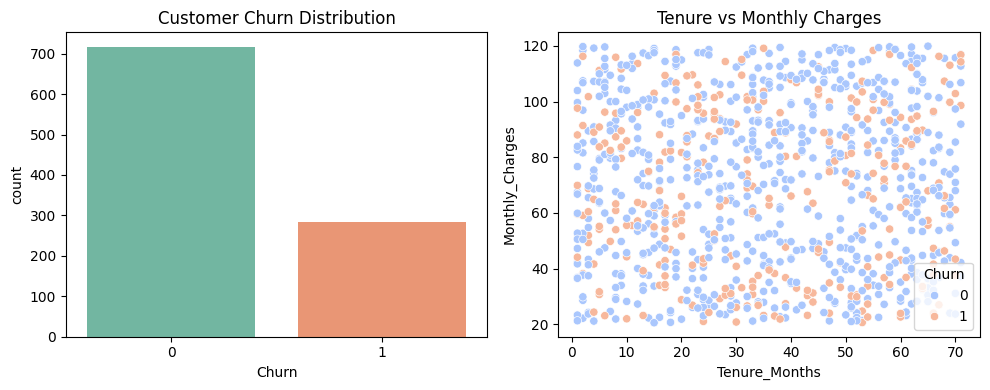

✅ Model, Web App file, and Charts successfully generated!


In [1]:
!pip install streamlit pyngrok -q

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

np.random.seed(42)
n_samples = 1000

df = pd.DataFrame({
    'Tenure_Months': np.random.randint(1, 72, n_samples),
    'Monthly_Charges': np.random.uniform(20.0, 120.0, n_samples),
    'Total_Charges': np.random.uniform(100.0, 8000.0, n_samples),
    'Contract_Type': np.random.choice([0, 1, 2], n_samples),
    'Tech_Support': np.random.choice([0, 1], n_samples),
    'Churn': np.random.choice([0, 1], n_samples, p=[0.7, 0.3])
})

from sklearn.ensemble import RandomForestClassifier
X = df.drop('Churn', axis=1)
y = df['Churn']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

app_code = """import streamlit as st
import pickle
import numpy as np

with open('churn_model.pkl', 'rb') as f:
    model = pickle.load(f)

st.title("📊 Customer Churn Prediction Web App")
st.write("Predict whether a customer is likely to churn or stay based on subscription patterns.")

st.sidebar.header("Customer Details")
tenure = st.sidebar.slider("Tenure (Months)", 1, 72, 12)
monthly = st.sidebar.number_input("Monthly Charges ($)", 20.0, 120.0, 65.0)
total = st.sidebar.number_input("Total Charges ($)", 100.0, 8000.0, 1500.0)
contract = st.sidebar.selectbox("Contract Type", ["Month-to-Month", "One Year", "Two Year"])
tech = st.sidebar.radio("Has Tech Support?", ["No", "Yes"])

contract_map = {"Month-to-Month": 0, "One Year": 1, "Two Year": 2}
tech_map = {"No": 0, "Yes": 1}

if st.button("Predict Churn Risk"):
    features = np.array([[tenure, monthly, total, contract_map[contract], tech_map[tech]]])
    prediction = model.predict(features)
    if prediction[0] == 1:
        st.error("🚨 High Risk: Customer is likely to Churn!")
    else:
        st.success("✅ Low Risk: Customer is likely to Stay Retained.")
"""

with open('app.py', 'w') as f:
    f.write(app_code)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Customer Churn Distribution')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Tenure_Months', y='Monthly_Charges', hue='Churn', palette='coolwarm')
plt.title('Tenure vs Monthly Charges')
plt.tight_layout()
plt.show()

print("✅ Model, Web App file, and Charts successfully generated!")

In [2]:
!pip install gradio -q
import gradio as gr
import pickle
import numpy as np

with open('churn_model.pkl', 'rb') as f:
    model = pickle.load(f)

def predict_churn(tenure, monthly, total, contract, tech):
    contract_map = {"Month-to-Month": 0, "One Year": 1, "Two Year": 2}
    tech_map = {"No": 0, "Yes": 1}
    features = np.array([[tenure, monthly, total, contract_map[contract], tech_map[tech]]])
    prediction = model.predict(features)
    return "🚨 High Risk: Customer is likely to Churn!" if prediction[0] == 1 else "✅ Low Risk: Customer is likely to Stay Retained."

interface = gr.Interface(
    fn=predict_churn,
    inputs=[
        gr.Slider(1, 72, value=12, label="Tenure (Months)"),
        gr.Number(value=65.0, label="Monthly Charges ($)"),
        gr.Number(value=1500.0, label="Total Charges ($)"),
        gr.Dropdown(["Month-to-Month", "One Year", "Two Year"], label="Contract Type"),
        gr.Radio(["No", "Yes"], label="Has Tech Support?")
    ],
    outputs="text",
    title="📊 Customer Churn Prediction Web App"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cfc6be7aff39be4ee9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
